## Dog Breed Identification 
#### By Sawyer Selby

### Installs

In [ ]:
## Uncomment the below line if you do not have the imports installed on your device locally:
## %pip install kaggle keras scikit-learn pandas matplotlib pillow
## Or in the terminal you can do: pip install kaggle keras scikit-learn pandas matplotlib pillow
## To run with CUDA uncomment below:
## %pip install torch --index-url https://download.pytorch.org/whl/cu128
## Or again in the terminal: pip install torch --index-url https://download.pytorch.org/whl/cu128

### Imports

In [2]:
import os
os.environ["KERAS_BACKEND"] = "torch" ## Run Keras on PyTorch. Must be set before importing Keras
import gc
import zipfile
from pathlib import Path

import numpy as np ## Arrays
import pandas as pd ## Tables
import matplotlib.pyplot as plt ## Plots
from PIL import Image ## Opening images
import torch ## Used to free GPU memory between models

import keras
from keras import layers

from sklearn.model_selection import train_test_split ## Train/validation/test split
from sklearn.preprocessing import StandardScaler ## Scaling for the baseline
from sklearn.metrics import confusion_matrix ## Error analysis

### Setup

In [3]:
DATA_DIR = "data" ## Folder for Kaggle data
COMPETITION = "dog-breed-identification"

tokenPath = Path.home() / ".kaggle" / "access_token"
os.environ["KAGGLE_API_TOKEN"] = tokenPath.read_text().strip()

from kaggle.api.kaggle_api_extended import KaggleApi

os.makedirs(DATA_DIR, exist_ok=True) ## Creates data folder

api = KaggleApi()
api.authenticate() ## Needs an API token to run. Place it in .kaggle/access_token in your home folder for it to authenticate and run

## Downloads the competion zip, skips if it is already there
zipPath = os.path.join(DATA_DIR, f"{COMPETITION}.zip")
if not os.path.exists(zipPath):
    api.competition_download_files(COMPETITION, path=DATA_DIR)

with zipfile.ZipFile(zipPath, "r") as z: ## Unzips the data, creats train, test, labesl.csv, sample_submission.csv
    z.extractall(DATA_DIR)

### Seed and Device

In [4]:
SEED = 42
keras.utils.set_random_seed(SEED) ## Same random numbers every run

### Labels

In [5]:
labels = pd.read_csv(os.path.join(DATA_DIR, "labels.csv")) ## Image ID and breed for every training image

counts = labels["breed"].value_counts()
print(f"{labels['breed'].nunique()} breeds, {counts.min()} to {counts.max()} images per breed")

120 breeds, 66 to 126 images per breed


### Visual of the dataset

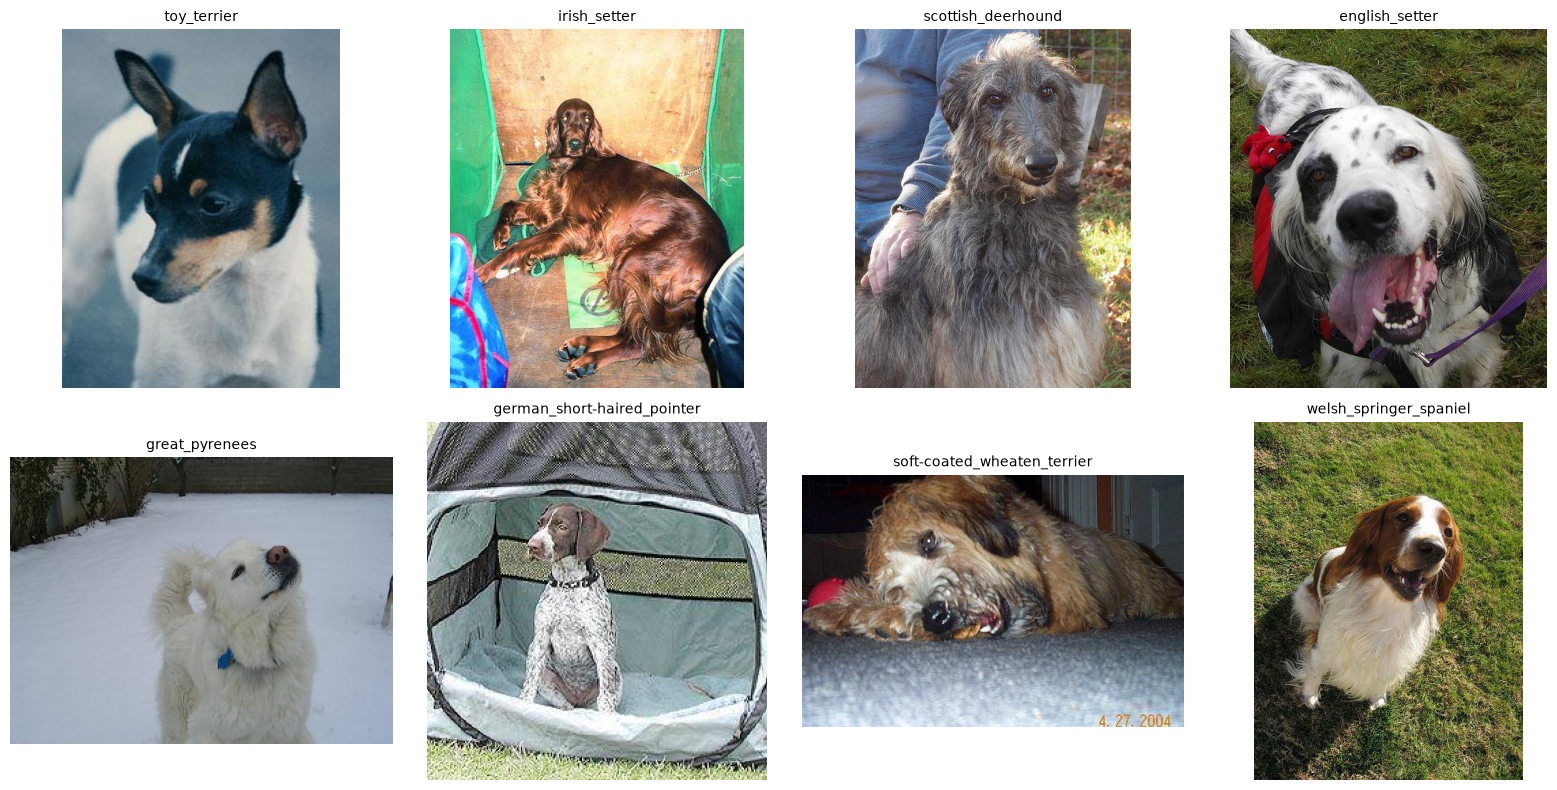

In [27]:
## A few example images with their breeds
sample = labels.sample(8, random_state=SEED)

plt.figure(figsize=(16, 8))
for k, (imgId, breed) in enumerate(zip(sample["id"], sample["breed"])):
    plt.subplot(2, 4, k + 1)
    plt.imshow(Image.open(os.path.join(DATA_DIR, "train", f"{imgId}.jpg")))
    plt.title(breed, fontsize=10)
    plt.axis("off")
plt.tight_layout(); plt.show()

### Split

In [6]:
# 20% test
trainValSplit, testSplit = train_test_split(
    labels,
    test_size=0.2,
    stratify=labels["breed"], ## Same breed mix in every split
    random_state=SEED,
)
## The rest is split into 60% training and 20% validation
trainSplit, valSplit = train_test_split(
    trainValSplit,
    test_size=0.25,
    stratify=trainValSplit["breed"],
    random_state=SEED,
)

print(f"Train: {len(trainSplit)}, Validation: {len(valSplit)}, Test: {len(testSplit)}")

## Check that no image is in more than one split
shared = (set(trainSplit["id"]) & set(valSplit["id"])) | (set(trainSplit["id"]) & set(testSplit["id"])) | (set(valSplit["id"]) & set(testSplit["id"]))
print("Images in more than one split:", len(shared))

## Save the splits
trainSplit.to_csv(os.path.join(DATA_DIR, "train_split.csv"), index=False)
valSplit.to_csv(os.path.join(DATA_DIR, "val_split.csv"), index=False)
testSplit.to_csv(os.path.join(DATA_DIR, "test_split.csv"), index=False)

Train: 6132, Validation: 2045, Test: 2045
Images in more than one split: 0


### Load and Flatten

In [7]:
IMG_SIZE = 32 ## Small images for the baseline

## Give each breed a number
breeds = sorted(labels["breed"].unique())
breedToIdx = {b: i for i, b in enumerate(breeds)}
NUM_CLASSES = len(breeds)

def load_flat(df):
    X = np.zeros((len(df), IMG_SIZE * IMG_SIZE * 3), dtype=np.float32)
    for i, imgId in enumerate(df["id"]):
        img = Image.open(os.path.join(DATA_DIR, "train", f"{imgId}.jpg")).convert("RGB")
        img = img.resize((IMG_SIZE, IMG_SIZE))
        X[i] = np.asarray(img, dtype=np.float32).reshape(-1) / 255.0 ## Flatten into one row of pixel values
    y = df["breed"].map(breedToIdx).to_numpy(dtype=np.int64) ## Breed names to numbers
    return X, y

xTrain, yTrain = load_flat(trainSplit)
xVal, yVal = load_flat(valSplit)
xTest, yTest = load_flat(testSplit)

## Scale using the training images only
scaler = StandardScaler()
xTrain = scaler.fit_transform(xTrain)
xVal = scaler.transform(xVal)
xTest = scaler.transform(xTest)

### Train Baseline

In [8]:
baseline = keras.Sequential([
    keras.Input(shape=(IMG_SIZE * IMG_SIZE * 3,)), ## One input per pixel
    layers.Dense(NUM_CLASSES, activation="softmax"), ## One output per breed. Softmax turns the scores into probabilities
])

baseline.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01), ## Plain SGD. Learning rate of 0.01
    loss="sparse_categorical_crossentropy", ## Cross-entropy equals log loss. "sparse" means the labels are numbers
    metrics=["accuracy"],
)

historyBaseline = baseline.fit(
    xTrain, yTrain,
    validation_data=(xVal, yVal), ## Scored on the validation set after every epoch
    epochs=30, ## Number of passes over the training set
    batch_size=128, ## Number of images per gradient update. One minibatch
    verbose=2, ## One line per epoch
)

Epoch 1/30
48/48 - 0s - 9ms/step - accuracy: 0.0122 - loss: 5.2560 - val_accuracy: 0.0210 - val_loss: 5.0198
Epoch 2/30
48/48 - 0s - 3ms/step - accuracy: 0.0258 - loss: 4.8344 - val_accuracy: 0.0254 - val_loss: 4.8889
Epoch 3/30
48/48 - 0s - 3ms/step - accuracy: 0.0382 - loss: 4.6308 - val_accuracy: 0.0279 - val_loss: 4.8379
Epoch 4/30
48/48 - 0s - 3ms/step - accuracy: 0.0502 - loss: 4.4844 - val_accuracy: 0.0293 - val_loss: 4.8003
Epoch 5/30
48/48 - 0s - 3ms/step - accuracy: 0.0628 - loss: 4.3654 - val_accuracy: 0.0323 - val_loss: 4.7811
Epoch 6/30
48/48 - 0s - 3ms/step - accuracy: 0.0729 - loss: 4.2619 - val_accuracy: 0.0323 - val_loss: 4.7678
Epoch 7/30
48/48 - 0s - 3ms/step - accuracy: 0.0912 - loss: 4.1696 - val_accuracy: 0.0333 - val_loss: 4.7557
Epoch 8/30
48/48 - 0s - 3ms/step - accuracy: 0.1008 - loss: 4.0875 - val_accuracy: 0.0357 - val_loss: 4.7517
Epoch 9/30
48/48 - 0s - 3ms/step - accuracy: 0.1142 - loss: 4.0115 - val_accuracy: 0.0391 - val_loss: 4.7430
Epoch 10/30
48/48 -

### Plot learning curves

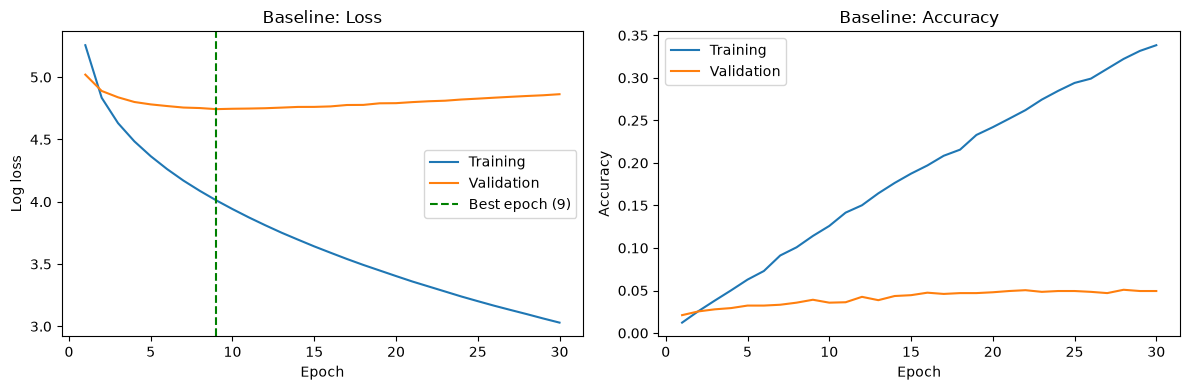

In [9]:
def plot_curves(history, title):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)
    bestEpoch = int(np.argmin(hist["val_loss"])) + 1 ## Epoch with the lowest validation loss

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ## Loss
    ax1.plot(epochs, hist["loss"], label="Training")
    ax1.plot(epochs, hist["val_loss"], label="Validation")
    ax1.axvline(bestEpoch, linestyle="--", color="green", label=f"Best epoch ({bestEpoch})")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Log loss")
    ax1.set_title(f"{title}: Loss"); ax1.legend()

    ## Accuracy
    ax2.plot(epochs, hist["accuracy"], label="Training")
    ax2.plot(epochs, hist["val_accuracy"], label="Validation")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.set_title(f"{title}: Accuracy"); ax2.legend()

    plt.tight_layout()
    plt.show()

plot_curves(historyBaseline, "Baseline")

### Baseline Test Score

In [10]:
results = [] ## One row per model

def record(name, history, model, xTestData, yTestData):
    testLoss, testAcc = model.evaluate(xTestData, yTestData, verbose=0) ## Score on the test set
    hist = history.history
    results.append({
        "Model": name,
        "Best val loss": min(hist["val_loss"]),
        "Best val acc": max(hist["val_accuracy"]),
        "Train acc": hist["accuracy"][-1],
        "Test loss": testLoss,
        "Test acc": testAcc,
    })

record("Baseline", historyBaseline, baseline, xTest, yTest)

### Load images at full size

In [11]:
RESNET_SIZE = 224 ## Image size ResNet-50 was trained on

def load_images(df):
    X = np.zeros((len(df), RESNET_SIZE, RESNET_SIZE, 3), dtype=np.uint8) ## Whole numbers to save memory
    for i, imgId in enumerate(df["id"]):
        img = Image.open(os.path.join(DATA_DIR, "train", f"{imgId}.jpg")).convert("RGB")
        X[i] = np.asarray(img.resize((RESNET_SIZE, RESNET_SIZE))) ## Keep the image shape. No flattening
    return X

imgTrain = load_images(trainSplit)
imgVal = load_images(valSplit)
imgTest = load_images(testSplit)

### Build the frozen model

In [12]:
base = keras.applications.ResNet50(
    weights="imagenet", ## Pretrained on ImageNet
    include_top=False, ## Remove the ImageNet output layer
    input_shape=(RESNET_SIZE, RESNET_SIZE, 3),
)
base.trainable = False ## Freeze all ResNet-50 layers

inputs = keras.Input(shape=(RESNET_SIZE, RESNET_SIZE, 3))
x = layers.Lambda(keras.applications.resnet50.preprocess_input)(inputs) ## Prepare pixels the way ResNet-50 expects
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x) ## New output layer for the 120 breeds

frozenModel = keras.Model(inputs, outputs)
frozenModel.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
frozenModel.summary() ## Shows trainable vs. frozen weights

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 120)            │       245,880 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,833,592 (90.92 MB)

 Trainable params: 245,880 (960.47 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

### Train the frozen model

Epoch 1/15
96/96 - 9s - 97ms/step - accuracy: 0.4561 - loss: 2.4095 - val_accuracy: 0.6592 - val_loss: 1.2418
Epoch 2/15
96/96 - 9s - 94ms/step - accuracy: 0.8271 - loss: 0.6679 - val_accuracy: 0.7291 - val_loss: 0.9496
Epoch 3/15
96/96 - 9s - 96ms/step - accuracy: 0.9175 - loss: 0.3760 - val_accuracy: 0.7389 - val_loss: 0.8828
Epoch 4/15
96/96 - 9s - 94ms/step - accuracy: 0.9625 - loss: 0.2347 - val_accuracy: 0.7565 - val_loss: 0.8456
Epoch 5/15
96/96 - 9s - 95ms/step - accuracy: 0.9814 - loss: 0.1587 - val_accuracy: 0.7565 - val_loss: 0.8310
Epoch 6/15
96/96 - 9s - 96ms/step - accuracy: 0.9915 - loss: 0.1144 - val_accuracy: 0.7531 - val_loss: 0.8309
Epoch 7/15
96/96 - 9s - 96ms/step - accuracy: 0.9948 - loss: 0.0869 - val_accuracy: 0.7643 - val_loss: 0.8092
Epoch 8/15
96/96 - 9s - 93ms/step - accuracy: 0.9984 - loss: 0.0658 - val_accuracy: 0.7614 - val_loss: 0.8081
Epoch 9/15
96/96 - 9s - 93ms/step - accuracy: 0.9985 - loss: 0.0539 - val_accuracy: 0.7677 - val_loss: 0.8120
Epoch 10/1

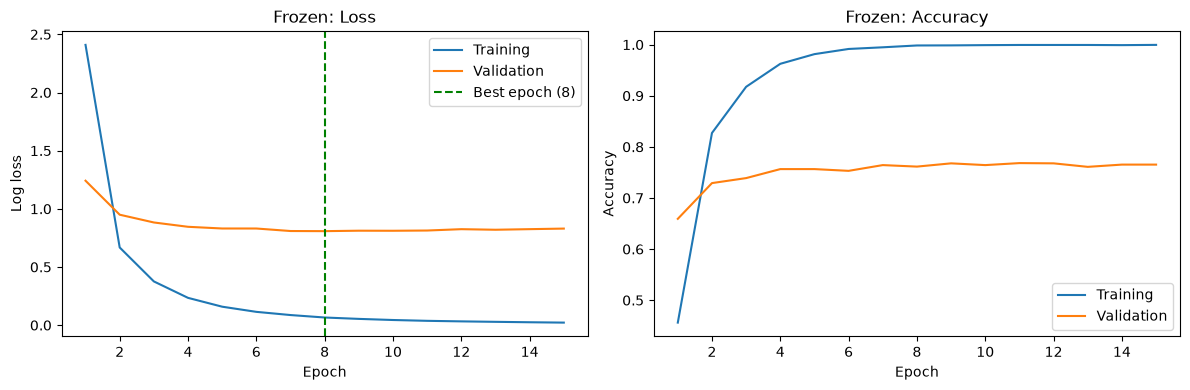

In [13]:
historyFrozen = frozenModel.fit(
    imgTrain, yTrain,
    validation_data=(imgVal, yVal),
    epochs=15,
    batch_size=64,
    verbose=2,
)

plot_curves(historyFrozen, "Frozen")
record("Frozen", historyFrozen, frozenModel, imgTest, yTest)

### Finetune the last block

In [14]:
base.trainable = True ## Make ResNet-50 trainable again.
for layer in base.layers:
    layer.trainable = layer.name.startswith("conv5_") ## Refreeze everything except the last block

print("Trainable ResNet-50 layers:", sum(layer.trainable for layer in base.layers), "of", len(base.layers))

Trainable ResNet-50 layers: 32 of 175


### Train with a small learning rate

Epoch 1/10
96/96 - 10s - 107ms/step - accuracy: 0.9972 - loss: 0.0595 - val_accuracy: 0.7565 - val_loss: 0.8574
Epoch 2/10
96/96 - 10s - 106ms/step - accuracy: 0.9990 - loss: 0.0297 - val_accuracy: 0.7599 - val_loss: 0.8749
Epoch 3/10
96/96 - 10s - 105ms/step - accuracy: 0.9993 - loss: 0.0225 - val_accuracy: 0.7594 - val_loss: 0.8829
Epoch 4/10
96/96 - 10s - 104ms/step - accuracy: 0.9995 - loss: 0.0173 - val_accuracy: 0.7619 - val_loss: 0.8855
Epoch 5/10
96/96 - 10s - 105ms/step - accuracy: 0.9992 - loss: 0.0154 - val_accuracy: 0.7609 - val_loss: 0.8845
Epoch 6/10
96/96 - 10s - 105ms/step - accuracy: 0.9993 - loss: 0.0126 - val_accuracy: 0.7594 - val_loss: 0.8827
Epoch 7/10
96/96 - 10s - 105ms/step - accuracy: 0.9993 - loss: 0.0109 - val_accuracy: 0.7609 - val_loss: 0.8825
Epoch 8/10
96/96 - 10s - 105ms/step - accuracy: 0.9995 - loss: 0.0095 - val_accuracy: 0.7619 - val_loss: 0.8814
Epoch 9/10
96/96 - 10s - 104ms/step - accuracy: 0.9992 - loss: 0.0085 - val_accuracy: 0.7614 - val_loss:

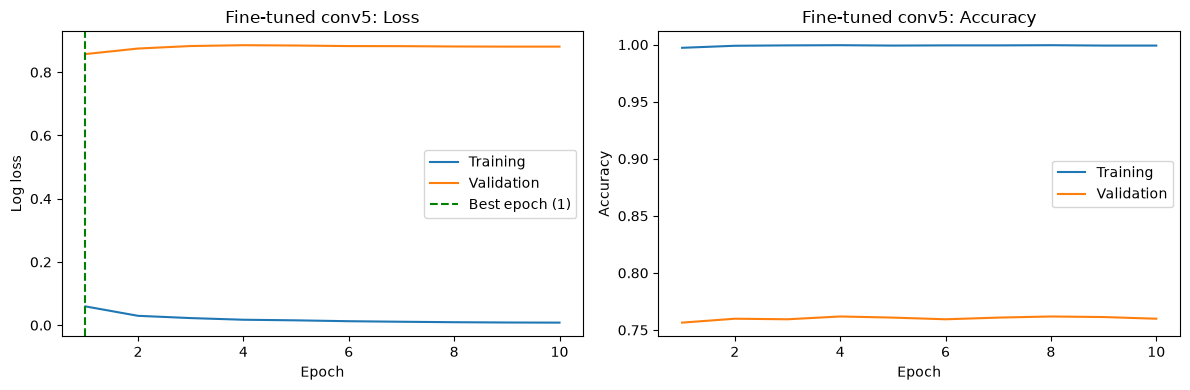

In [15]:
## Recompile so the change takes effect
frozenModel.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5), ## Small steps to keep the pretrained weights
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

historyFineTuned = frozenModel.fit(
    imgTrain, yTrain,
    validation_data=(imgVal, yVal),
    epochs=10,
    batch_size=64,
    verbose=2,
)

plot_curves(historyFineTuned, "Fine-tuned conv5")
record("Fine-tuned conv5", historyFineTuned, frozenModel, imgTest, yTest)

### Experiment function

In [16]:
## Builds and trains a fresh frozen ResNet-50 with one change at a time
def build_and_train(augment=False, dropout=0.0, earlyStop=False):
    ## Free GPU memory from the last model
    keras.backend.clear_session()
    gc.collect()
    torch.cuda.empty_cache()

    keras.utils.set_random_seed(SEED) ## Same start for every experiment

    base = keras.applications.ResNet50(weights="imagenet", include_top=False,
                                       input_shape=(RESNET_SIZE, RESNET_SIZE, 3))
    base.trainable = False

    inputs = keras.Input(shape=(RESNET_SIZE, RESNET_SIZE, 3))
    x = inputs
    if augment:
        x = layers.RandomFlip("horizontal")(x) ## Randomly mirror training images
    x = layers.Lambda(keras.applications.resnet50.preprocess_input)(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    if dropout > 0:
        x = layers.Dropout(dropout)(x) ## Randomly turn off features while training
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = keras.Model(inputs, outputs)

    callbacks = []
    if earlyStop: ## Stop when validation loss stops improving and keep the best epoch
        callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    history = model.fit(imgTrain, yTrain, validation_data=(imgVal, yVal),
                        epochs=15, batch_size=64, callbacks=callbacks, verbose=2)
    return model, history

## Train, plot, and record one experiment
def run(name, **changes):
    model, history = build_and_train(**changes)
    plot_curves(history, name)
    record(name, history, model, imgTest, yTest)
    return model

### Experiments

W1007 17:41:10.792000 24464 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Epoch 1/15
96/96 - 9s - 96ms/step - accuracy: 0.4527 - loss: 2.4276 - val_accuracy: 0.6655 - val_loss: 1.2359
Epoch 2/15
96/96 - 9s - 94ms/step - accuracy: 0.8299 - loss: 0.6720 - val_accuracy: 0.7105 - val_loss: 0.9682
Epoch 3/15
96/96 - 9s - 94ms/step - accuracy: 0.9163 - loss: 0.3767 - val_accuracy: 0.7452 - val_loss: 0.8870
Epoch 4/15
96/96 - 9s - 94ms/step - accuracy: 0.9646 - loss: 0.2359 - val_accuracy: 0.7452 - val_loss: 0.8676
Epoch 5/15
96/96 - 9s - 94ms/step - accuracy: 0.9811 - loss: 0.1627 - val_accuracy: 0.7511 - val_loss: 0.8412
Epoch 6/15
96/96 - 9s - 94ms/step - accuracy: 0.9889 - loss: 0.1168 - val_accuracy: 0.7545 - val_loss: 0.8223
Epoch 7/15
96/96 - 9s - 94ms/step - accuracy: 0.9958 - loss: 0.0865 - val_accuracy: 0.7579 - val_loss: 0.8167
Epoch 8/15
96/96 - 9s - 94ms/step - accuracy: 0.9977 - loss: 0.0673 - val_accuracy: 0.7575 - val_loss: 0.8223
Epoch 9/15
96/96 - 9s - 94ms/step - accuracy: 0.9984 - loss: 0.0549 - val_accuracy: 0.7648 - val_loss: 0.8344
Epoch 10/1

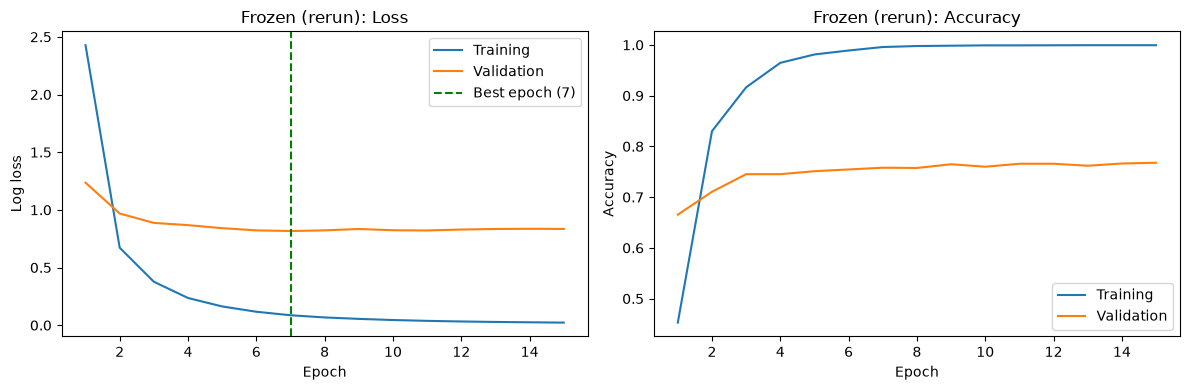

In [17]:
_ = run("Frozen (rerun)")

Epoch 1/15
96/96 - 9s - 96ms/step - accuracy: 0.4527 - loss: 2.4276 - val_accuracy: 0.6655 - val_loss: 1.2359
Epoch 2/15
96/96 - 9s - 95ms/step - accuracy: 0.8299 - loss: 0.6720 - val_accuracy: 0.7105 - val_loss: 0.9682
Epoch 3/15
96/96 - 9s - 94ms/step - accuracy: 0.9163 - loss: 0.3767 - val_accuracy: 0.7452 - val_loss: 0.8870
Epoch 4/15
96/96 - 9s - 95ms/step - accuracy: 0.9646 - loss: 0.2359 - val_accuracy: 0.7452 - val_loss: 0.8676
Epoch 5/15
96/96 - 9s - 94ms/step - accuracy: 0.9811 - loss: 0.1627 - val_accuracy: 0.7511 - val_loss: 0.8412
Epoch 6/15
96/96 - 9s - 95ms/step - accuracy: 0.9889 - loss: 0.1168 - val_accuracy: 0.7545 - val_loss: 0.8223
Epoch 7/15
96/96 - 9s - 94ms/step - accuracy: 0.9958 - loss: 0.0865 - val_accuracy: 0.7579 - val_loss: 0.8167
Epoch 8/15
96/96 - 9s - 94ms/step - accuracy: 0.9977 - loss: 0.0673 - val_accuracy: 0.7575 - val_loss: 0.8223
Epoch 9/15
96/96 - 9s - 94ms/step - accuracy: 0.9984 - loss: 0.0549 - val_accuracy: 0.7648 - val_loss: 0.8344
Epoch 10/1

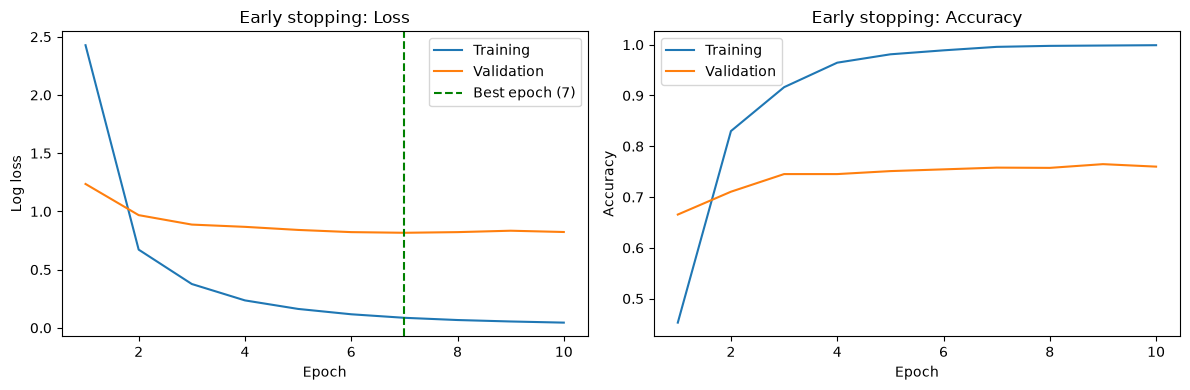

In [18]:
_ = run("Early stopping", earlyStop=True)

Epoch 1/15
96/96 - 9s - 96ms/step - accuracy: 0.2714 - loss: 3.3271 - val_accuracy: 0.6377 - val_loss: 1.3915
Epoch 2/15
96/96 - 9s - 94ms/step - accuracy: 0.6518 - loss: 1.2457 - val_accuracy: 0.7110 - val_loss: 1.0019
Epoch 3/15
96/96 - 9s - 94ms/step - accuracy: 0.7560 - loss: 0.8254 - val_accuracy: 0.7418 - val_loss: 0.9000
Epoch 4/15
96/96 - 9s - 94ms/step - accuracy: 0.8182 - loss: 0.6046 - val_accuracy: 0.7443 - val_loss: 0.8761
Epoch 5/15
96/96 - 9s - 94ms/step - accuracy: 0.8567 - loss: 0.4860 - val_accuracy: 0.7428 - val_loss: 0.8479
Epoch 6/15
96/96 - 9s - 94ms/step - accuracy: 0.8857 - loss: 0.3857 - val_accuracy: 0.7575 - val_loss: 0.8298
Epoch 7/15
96/96 - 9s - 94ms/step - accuracy: 0.9017 - loss: 0.3284 - val_accuracy: 0.7653 - val_loss: 0.8281
Epoch 8/15
96/96 - 9s - 94ms/step - accuracy: 0.9150 - loss: 0.2943 - val_accuracy: 0.7550 - val_loss: 0.8368
Epoch 9/15
96/96 - 9s - 94ms/step - accuracy: 0.9331 - loss: 0.2398 - val_accuracy: 0.7472 - val_loss: 0.8490
Epoch 10/1

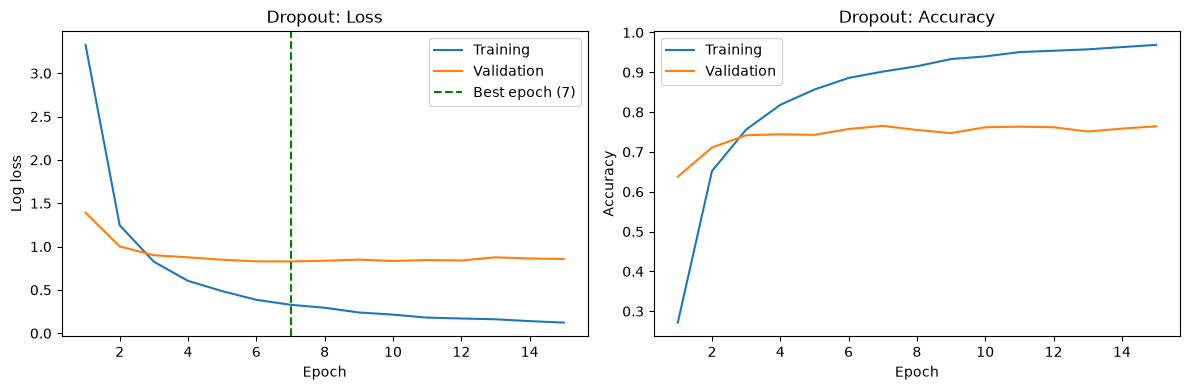

In [19]:
_ = run("Dropout", dropout=0.5)

Epoch 1/15
96/96 - 10s - 103ms/step - accuracy: 0.4434 - loss: 2.4272 - val_accuracy: 0.6670 - val_loss: 1.2471
Epoch 2/15
96/96 - 9s - 94ms/step - accuracy: 0.8297 - loss: 0.6871 - val_accuracy: 0.7139 - val_loss: 0.9542
Epoch 3/15
96/96 - 9s - 95ms/step - accuracy: 0.9093 - loss: 0.3984 - val_accuracy: 0.7506 - val_loss: 0.8719
Epoch 4/15
96/96 - 9s - 94ms/step - accuracy: 0.9486 - loss: 0.2633 - val_accuracy: 0.7526 - val_loss: 0.8464
Epoch 5/15
96/96 - 9s - 94ms/step - accuracy: 0.9762 - loss: 0.1826 - val_accuracy: 0.7545 - val_loss: 0.8324
Epoch 6/15
96/96 - 9s - 94ms/step - accuracy: 0.9832 - loss: 0.1364 - val_accuracy: 0.7560 - val_loss: 0.8112
Epoch 7/15
96/96 - 9s - 94ms/step - accuracy: 0.9933 - loss: 0.1020 - val_accuracy: 0.7628 - val_loss: 0.8103
Epoch 8/15
96/96 - 9s - 94ms/step - accuracy: 0.9959 - loss: 0.0804 - val_accuracy: 0.7628 - val_loss: 0.8146
Epoch 9/15
96/96 - 9s - 94ms/step - accuracy: 0.9964 - loss: 0.0681 - val_accuracy: 0.7604 - val_loss: 0.8248
Epoch 10

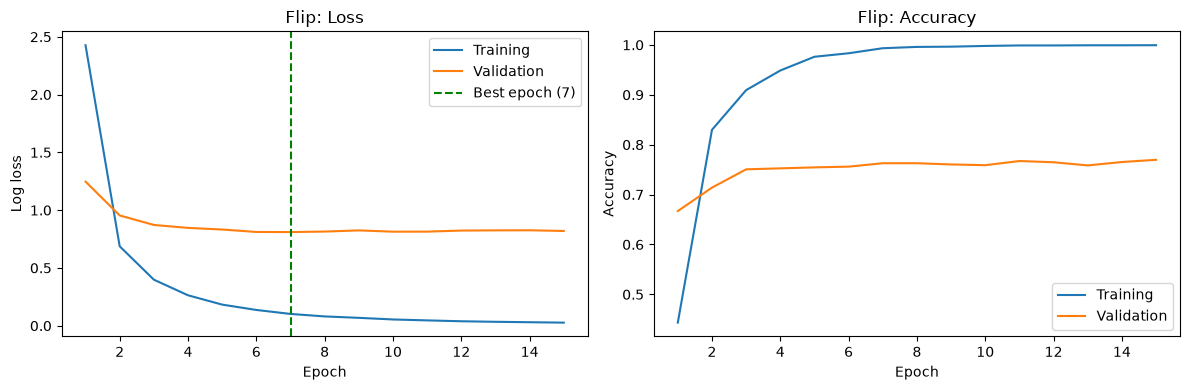

In [20]:
_ = run("Flip", augment=True)

Epoch 1/15
96/96 - 9s - 97ms/step - accuracy: 0.4434 - loss: 2.4272 - val_accuracy: 0.6670 - val_loss: 1.2471
Epoch 2/15
96/96 - 9s - 95ms/step - accuracy: 0.8297 - loss: 0.6871 - val_accuracy: 0.7139 - val_loss: 0.9542
Epoch 3/15
96/96 - 9s - 95ms/step - accuracy: 0.9093 - loss: 0.3984 - val_accuracy: 0.7506 - val_loss: 0.8719
Epoch 4/15
96/96 - 9s - 95ms/step - accuracy: 0.9486 - loss: 0.2633 - val_accuracy: 0.7526 - val_loss: 0.8464
Epoch 5/15
96/96 - 9s - 95ms/step - accuracy: 0.9762 - loss: 0.1826 - val_accuracy: 0.7545 - val_loss: 0.8324
Epoch 6/15
96/96 - 9s - 95ms/step - accuracy: 0.9832 - loss: 0.1364 - val_accuracy: 0.7560 - val_loss: 0.8112
Epoch 7/15
96/96 - 9s - 95ms/step - accuracy: 0.9933 - loss: 0.1020 - val_accuracy: 0.7628 - val_loss: 0.8103
Epoch 8/15
96/96 - 9s - 94ms/step - accuracy: 0.9959 - loss: 0.0804 - val_accuracy: 0.7628 - val_loss: 0.8146
Epoch 9/15
96/96 - 9s - 95ms/step - accuracy: 0.9964 - loss: 0.0681 - val_accuracy: 0.7604 - val_loss: 0.8248
Epoch 10/1

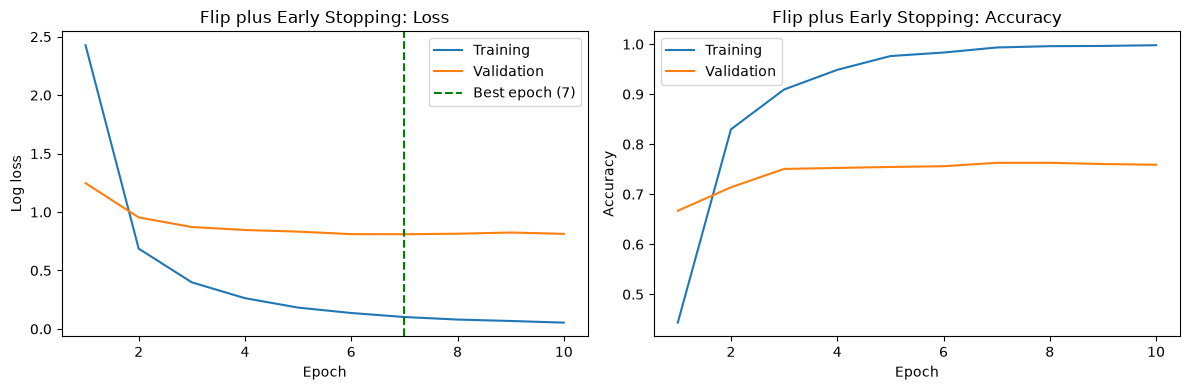

In [21]:
finalModel = run("Flip plus Early Stopping", augment=True, earlyStop=True)

### All results

In [22]:
display(pd.DataFrame(results).round(4))

,Model,Best val loss,Best val acc,Train acc,Test loss,Test acc
0,Baseline,4.7430,0.0509,0.3384,4.8718,0.0377
1,Frozen,0.8081,0.7682,0.9995,0.8322,0.7584
2,Fine-tuned conv5,0.8574,0.7619,0.9992,0.8783,0.7545
3,Frozen (rerun),0.8167,0.7677,0.9993,0.8117,0.7677
4,Early stopping,0.8167,0.7648,0.9990,0.7979,0.7594
5,Dropout,0.8281,0.7653,0.9687,0.8697,0.7496
6,Flip,0.8103,0.7697,0.9993,0.8292,0.7628
7,Flip plus Early Stopping,0.8103,0.7628,0.9979,0.8174,0.7570


### Error analysis

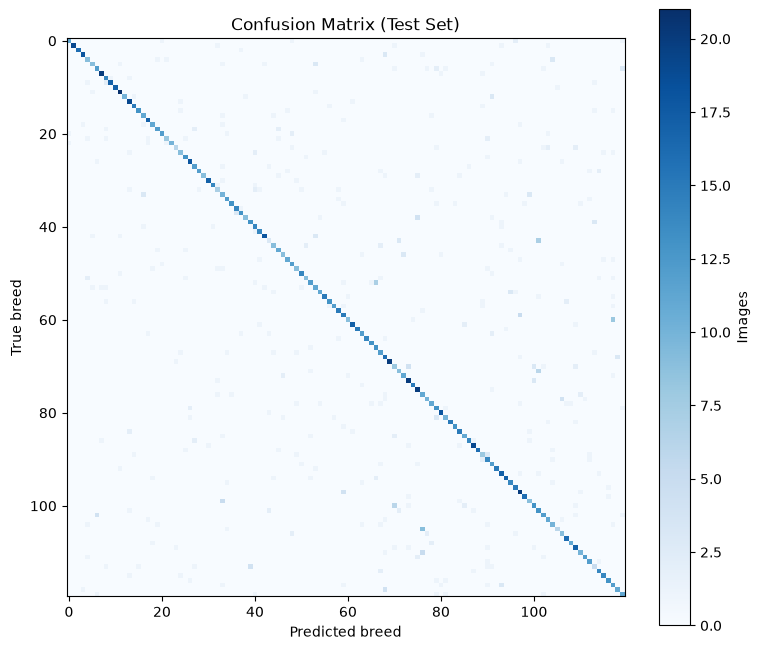

In [23]:
probs = finalModel.predict(imgTest, batch_size=64, verbose=0) ## Probability for each breed
preds = probs.argmax(axis=1) ## Most likely breed
cm = confusion_matrix(yTest, preds, labels=np.arange(NUM_CLASSES))

plt.figure(figsize=(9, 8))
plt.imshow(cm, cmap="Blues")
plt.colorbar(label="Images")
plt.xlabel("Predicted breed"); plt.ylabel("True breed")
plt.title("Confusion Matrix (Test Set)")
plt.show()

### Most confused breeds and weakest breeds

In [24]:
mistakes = cm.copy()
np.fill_diagonal(mistakes, 0) ## Keep only wrong predictions

## 10 most common mistakes
topIdx = np.argsort(mistakes, axis=None)[::-1][:10]
rows, cols = np.unravel_index(topIdx, mistakes.shape)
confusedPairs = pd.DataFrame({
    "True": [breeds[r] for r in rows],
    "Predicted": [breeds[c] for c in cols],
    "Count": [mistakes[r, c] for r, c in zip(rows, cols)],
})
display(confusedPairs)

## 10 breeds with the lowest accuracy
breedAcc = cm.diagonal() / cm.sum(axis=1)
worstBreeds = pd.DataFrame({"Breed": breeds, "Accuracy": breedAcc}).sort_values("Accuracy").head(10)

,True,Predicted,Count
0,standard_poodle,miniature_poodle,9
1,italian_greyhound,whippet,8
2,great_pyrenees,kuvasz,7
3,eskimo_dog,siberian_husky,7
4,shih-tzu,lhasa,6
5,malamute,siberian_husky,6
6,shetland_sheepdog,collie,5
7,irish_wolfhound,scottish_deerhound,5
8,toy_poodle,miniature_poodle,5
9,wire-haired_fox_terrier,lakeland_terrier,4


### Most confident mistakes

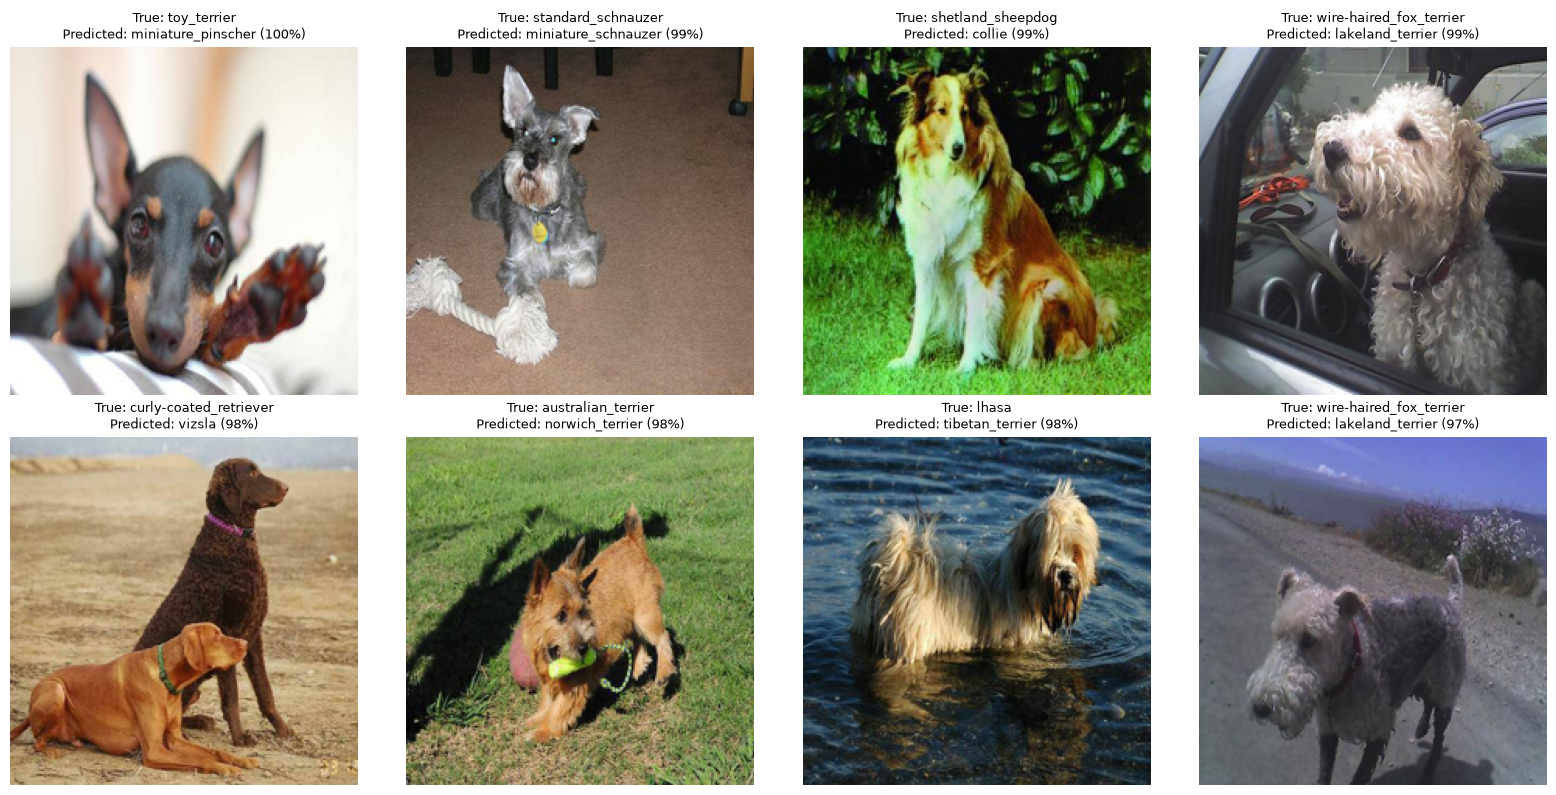

In [25]:
wrong = np.where(preds != yTest)[0] ## Test images the model got wrong
wrongConf = probs[wrong, preds[wrong]] ## How confident it was in the wrong answer
show = wrong[np.argsort(wrongConf)[::-1][:8]] ## The 8 most confident mistakes

plt.figure(figsize=(16, 8))
for k, i in enumerate(show):
    plt.subplot(2, 4, k + 1)
    plt.imshow(imgTest[i])
    plt.title(f"True: {breeds[yTest[i]]}\nPredicted: {breeds[preds[i]]} ({probs[i, preds[i]]:.0%})", fontsize=9)
    plt.axis("off")
plt.tight_layout(); plt.show()

### Comparison with the published results

In [26]:
baseRow, finalRow = results[0], results[-1]

comparison = pd.DataFrame([
    {"Model": "Baseline (ours)", "Test set": "Our split", "Accuracy": baseRow["Test acc"], "Log loss": baseRow["Test loss"]},
    {"Model": "ResNet-50 final (ours)", "Test set": "Our split", "Accuracy": finalRow["Test acc"], "Log loss": finalRow["Test loss"]},
    {"Model": "GoogLeNet (Sermanet et al., 2014)", "Test set": "Stanford Dogs", "Accuracy": 0.755, "Log loss": None},
    {"Model": "ResNet-50 (Nguyen et al., PCNN)", "Test set": "Stanford Dogs", "Accuracy": 0.8582, "Log loss": None},
    {"Model": "Pretrained CNNs (Vadla, Kaggle)", "Test set": "Kaggle leaderboard", "Accuracy": None, "Log loss": 0.2589},
])
display(comparison.round(4))

,Model,Test set,Accuracy,Log loss
0,Baseline (ours),Our split,0.0377,4.8718
1,ResNet-50 final (ours),Our split,0.7570,0.8174
2,"GoogLeNet (Sermanet et al., 2014)",Stanford Dogs,0.7550,NaN
3,"ResNet-50 (Nguyen et al., PCNN)",Stanford Dogs,0.8582,NaN
4,"Pretrained CNNs (Vadla, Kaggle)",Kaggle leaderboard,NaN,0.2589
